Importing libraries and models

In [2]:
import requests
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertModel, BertForSequenceClassification
import torch

!pip install scikit-dimension
import skdim
from skdim.id import TwoNN, MLE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Accessing BERT tokeniser and base model

In [3]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_hidden_states=True
)

device = torch.device("cuda")
model.to(device)
model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Downloading corpus data

In [4]:
keyword = "language"
# github link for csv file
url = f"https://raw.githubusercontent.com/wsteinberg1/UPF-NLP-3/main/sketch_engine_{keyword}10k.csv"

In [5]:
# Putting data in dataframe
df_raw = pd.read_csv(
    url,
    skiprows=5,                # skip metadata
    names=["date", "left", "kwic", "right"],
    dtype=str,
    on_bad_lines='skip'
)

df_data = df_raw.copy()


Processing Data

In [6]:
# Removing sketch engine formatting markers
df_data["left"] = df_data["left"].apply(lambda x: x.replace(" </s><s> ", " "))
df_data["right"] = df_data["right"].apply(lambda x: x.replace(" </s><s> ", " "))
df_data["full_sen"] = df_data["left"] + " " + df_data["kwic"] + " " + df_data["right"]
df_data


,date,left,kwic,right,full_sen
0,2014-01-05,"scores in reading, math and science despite a ...",language,. It is too soon to credit the new board and s...,"scores in reading, math and science despite a ..."
1,2014-01-30,handicap. McMullan is a 22-handicapper and Cat...,language,requirements for EU health professionals and a...,handicap. McMullan is a 22-handicapper and Cat...
2,2014-02-13,man in his 59s and an Ethiopian housemaid in a...,language,daily Okaz said. Indian man found dead at Saud...,man in his 59s and an Ethiopian housemaid in a...
3,2014-04-16,"situations, the less uncomfortable they become...",language,", non-verbal communication becomes even more e...","situations, the less uncomfortable they become..."
4,2014-04-22,from the Minister of Labour advising that no m...,language,from the Ontario legislation (section 79): 79....,from the Minister of Labour advising that no m...
...,...,...,...,...,...
9995,2026-03-09,in our first bargaining session. The company r...,language,in the Times Tech Guild contract. That languag...,in our first bargaining session. The company r...
9996,2026-03-06,responses and are unable to move beyond the sc...,language,"barriers? Yes, the rep''s instructions were mi...",responses and are unable to move beyond the sc...
9997,2026-03-04,blow struck in the cause of Irish unification....,language,", I don''t think it''s doing those who would b...",blow struck in the cause of Irish unification....
9998,2026-03-09,core state investments. The European Union''s ...,language,". The EU called for an ""evidence-based, integr...",core state investments. The European Union''s ...


In [8]:
# Finding tokeniser id of keyword
word_id = tokenizer(keyword)["input_ids"][1]
print(word_id)
tokenizer(keyword)

2653


{'input_ids': [101, 2653, 102], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}

Constructing Helper Functions

In [9]:
# Accessings embedding vector values
def get_embeddings(text, token):
  inputs = tokenizer(text, return_tensors="pt").to(device)
  token_idx = inputs["input_ids"].tolist()[0].index(token)

  with torch.no_grad():
      outputs = model(**inputs)
  hidden_states = outputs.hidden_states

  return [layer[:, token_idx, :].cpu().numpy() for layer in outputs.hidden_states]


Extracting vectors for each context

In [10]:
df_data["vecs"] = df_data["full_sen"].apply(lambda x: get_embeddings(x, word_id))
# Extracts the vector at layer 8
df_data["vec_final"] = df_data["vecs"].apply(lambda x: x[8][0])


# Removing repeated contexts
df_data = df_data.groupby(["full_sen"]).head(1)
# Randomising order
df_data = df_data.sample(frac=1).reset_index(drop=True)

Calculating ID values

In [1]:
# Batch size for ID calculations
step = 100

# Puts the vectors for the ID calculation in a list
X = np.stack(df_data[f"vec_final"].values)
X = X[~np.isnan(X).any(axis=1)]


NameError: name 'np' is not defined

In [15]:
# Calculating ID estimates for TwoNN method
twonn_data = []
sample_data = []

for i in range(step-1, len(X), step):
  Y = X[0:i]
  id_est1 = TwoNN().fit(Y).dimension_
  twonn_data.append(id_est1)
  sample_data.append(i+1)

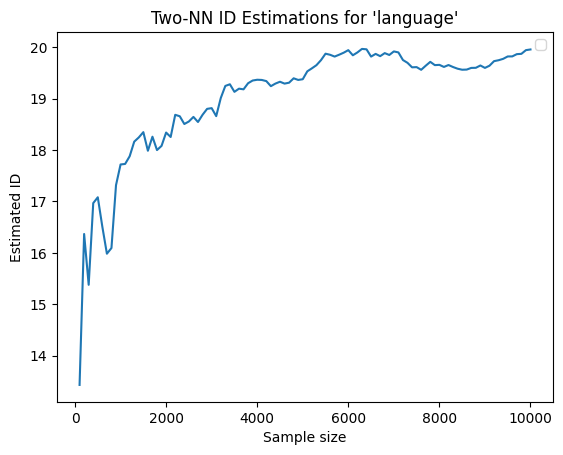

In [16]:
#Graph of TwoNN ID estimates
plt.plot(sample_data, twonn_data)
plt.ylabel("Estimated ID")
plt.xlabel(f"Sample size")
plt.title(f"Two-NN ID Estimations for '{keyword}'")
plt.legend()
plt.show()

In [17]:
# Calculating ID estimates with MLE default method
mle_data_0 = []
sample_data = []
for i in range(step-1, len(X), step):
  Y = X[0:i]
  id_est2 = MLE().fit(Y).dimension_
  mle_data_0.append(id_est2)
  sample_data.append(i+1)


In [18]:
# Recording results for all MLE methods
mle_all_data = []

In [21]:
# MLE ID estimates for K = 2, 3, 4, 5
for param in range(2, 6):
  mle_data = []
  sample_data = []
  for i in range(step-1, len(X), step):
    Y = X[0:i]
    id_est2 = MLE(neighborhood_based = True).fit(Y, comb="mle", n_neighbors=param).dimension_
    mle_data.append(id_est2)
    sample_data.append(i+1)

  mle_all_data.append([param, mle_data])

Graphing the results

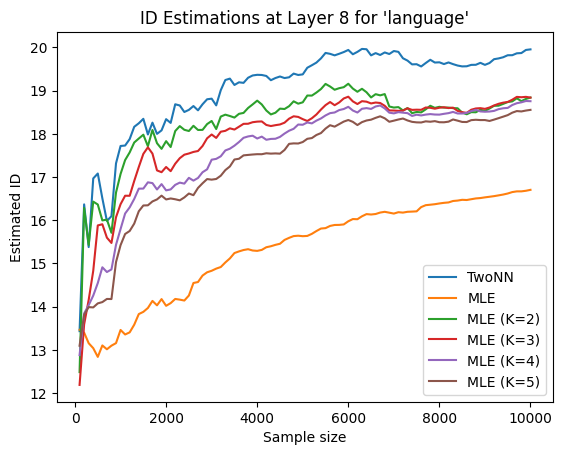

In [26]:
# Plotting all ID estimates for the keyword
plt.plot(sample_data, twonn_data, label = "TwoNN")
plt.plot(sample_data, mle_data_0, label = "MLE")
for pair in mle_all_data:
  param = pair[0]
  mle_data = pair[1]
  plt.plot(sample_data, mle_data, label = f"MLE (K={param})")
plt.ylabel("Estimated ID")
plt.xlabel("Sample size")
plt.title(f"ID Estimations at Layer 8 for '{keyword}'")
plt.legend()
plt.show()

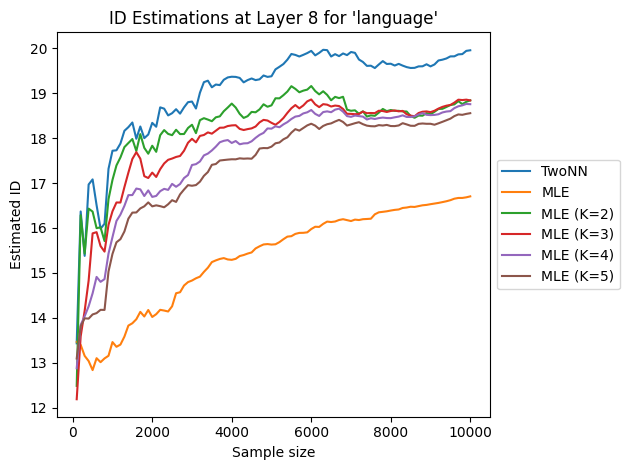

In [27]:
# Second plot, it was getting crowded in the one above sometimes
plt.plot(sample_data, twonn_data, label = "TwoNN")
plt.plot(sample_data, mle_data_0, label = "MLE")
for pair in mle_all_data:
  param = pair[0]
  mle_data = pair[1]
  plt.plot(sample_data, mle_data, label = f"MLE (K={param})")
plt.ylabel("Estimated ID")
plt.xlabel("Sample size")
plt.title(f"ID Estimations at Layer 8 for '{keyword}'")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [24]:
# Recording the data so I don't lose it
all_data = mle_all_data.copy()
all_data.append(["MLE", mle_data_0])
all_data.append(["TwoNN", twonn_data])

file_path = f"/content/drive/MyDrive/nlp3_l8_{keyword}.txt"
with open(file_path, "w") as f:
    json.dump(all_data, f)

In [25]:
# Reaccessing the data
file_path = f"/content/drive/MyDrive/nlp3_l8_{keyword}.txt"
with open(file_path, "r") as f:
    loaded_list = json.load(f)
loaded_list[5]

['TwoNN',
 [13.43146355062718,
  16.366275920453294,
  15.37798620178497,
  16.966615755741895,
  17.080244020294064,
  16.506709470824482,
  15.982763902451463,
  16.093157860778398,
  17.31522691668293,
  17.718028069246376,
  17.728006624538114,
  17.877768286044432,
  18.161638295046476,
  18.24333125317567,
  18.34658271028682,
  17.984601641340845,
  18.257671324922562,
  17.998184385669376,
  18.079536729518946,
  18.338499009492576,
  18.25217895143833,
  18.683468629552415,
  18.65533653558711,
  18.504716156694755,
  18.553742867342397,
  18.642602360725526,
  18.54337093550319,
  18.683620294387378,
  18.799024780483403,
  18.813188843016924,
  18.65785140567832,
  19.009219152459835,
  19.244957930147322,
  19.277518555576314,
  19.13027866996837,
  19.191755778161035,
  19.179151792191217,
  19.2976149836884,
  19.35019801781237,
  19.365328510236925,
  19.361498264825077,
  19.338937369627587,
  19.24048719412945,
  19.290825331432927,
  19.3265361278196,
  19.29033550288